In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings("ignore")

plt.rcParams['font.family'] ="Malgun Gothic"
plt.rcParams['axes.unicode_minus']=False

In [2]:
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima

In [3]:
df = pd.read_csv('../시계열/data/international-airline-passengers.txt', index_col=0, parse_dates=True)
df

,passengers
time,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [4]:
# EDA 수행: 기술통계값 등

df.describe()

,passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


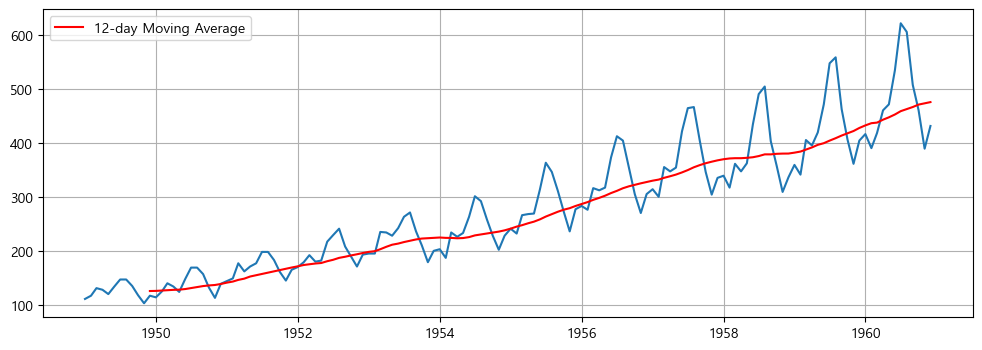

In [5]:
df["MA_12"] = df["passengers"].rolling(window=12).mean()

plt.figure(figsize=(12, 4))
plt.plot(df.index, df['passengers'])
plt.plot(df["MA_12"], label="12-day Moving Average", color='red')
plt.legend()
plt.grid(True)
plt.show()

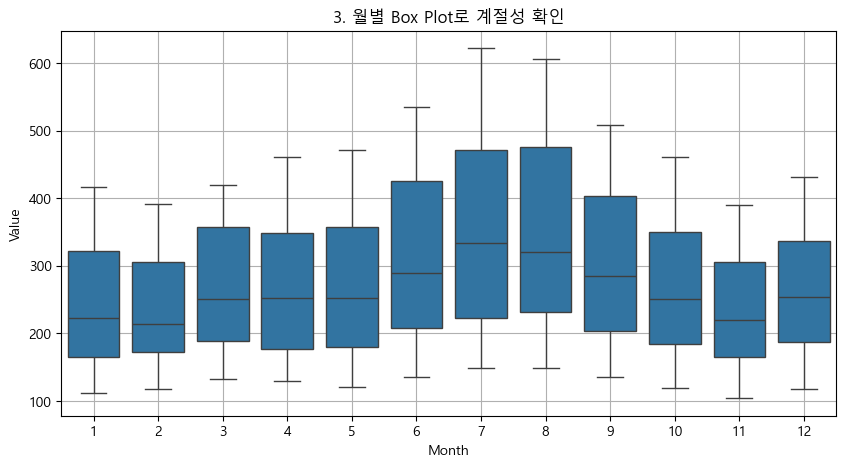

In [6]:
df["month"] = df.index.month

plt.figure(figsize=(10, 5))
sns.boxplot(x="month", y="passengers", data=df)
plt.title("3. 월별 Box Plot로 계절성 확인")
plt.xlabel("Month")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [7]:
passengers = df['passengers'].values

In [8]:
np.corrcoef(passengers[1:], passengers[:-1])

array([[1.        , 0.96019465],
       [0.96019465, 1.        ]])

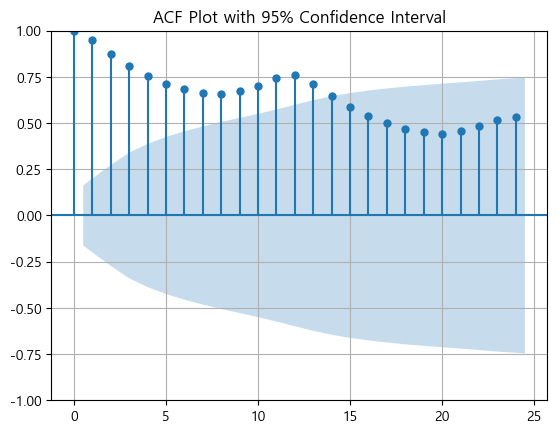

Lag별 p-value
Lag 1: p-value = 0.0000
Lag 2: p-value = 0.0000
Lag 3: p-value = 0.0000
Lag 4: p-value = 0.0000
Lag 5: p-value = 0.0000
Lag 6: p-value = 0.0000
Lag 7: p-value = 0.0000
Lag 8: p-value = 0.0000
Lag 9: p-value = 0.0000
Lag 10: p-value = 0.0000
Lag 11: p-value = 0.0000
Lag 12: p-value = 0.0000
Lag 13: p-value = 0.0000
Lag 14: p-value = 0.0000
Lag 15: p-value = 0.0000
Lag 16: p-value = 0.0000
Lag 17: p-value = 0.0000
Lag 18: p-value = 0.0000
Lag 19: p-value = 0.0000
Lag 20: p-value = 0.0000
Lag 21: p-value = 0.0000
Lag 22: p-value = 0.0000
Lag 23: p-value = 0.0000
Lag 24: p-value = 0.0000
 자기상관 있음 → 비정상 가능성 높음


In [9]:
# acf, pacf 그래프 ,adfuller지수 시계열확인

from statsmodels.tsa.stattools import acf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

acf_vals, confint, qstat, pvalues = acf(passengers, nlags=24, alpha=0.05, qstat=True)

#  ACF 그래프 그리기
plot_acf(passengers, lags=24, alpha=0.05)
plt.title("ACF Plot with 95% Confidence Interval")
plt.grid(True)
plt.show()

#  각 lag에 대한 p-value 출력
print("Lag별 p-value")
for i, p in enumerate(pvalues):
    print(f"Lag {i+1}: p-value = {p:.4f}")

if pvalues[-1] < 0.05:
    print(" 자기상관 있음 → 비정상 가능성 높음")
else:
    print(" 자기상관 없음 → 정상 시계열 가능성 있음")

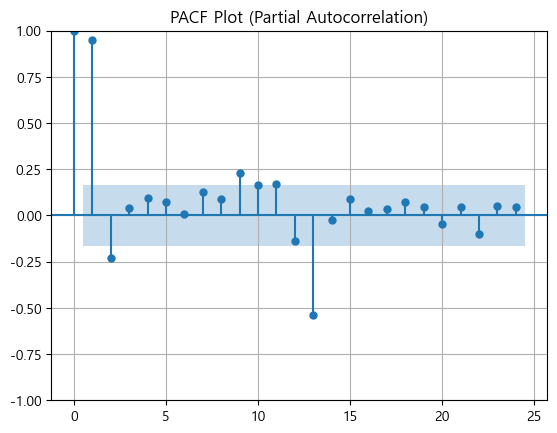

In [10]:
plot_pacf(passengers, lags=24, method='ywm')
plt.title("PACF Plot (Partial Autocorrelation)")
plt.grid(True)
plt.show()

In [11]:
result = adfuller(passengers)
print("ADF Test")
print(f"ADF 통계량: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

if result[1] < 0.05:
    print("✅ 정상 시계열 (stationary)")
else:
    print("❌ 비정상 시계열 (non-stationary)")

ADF Test
ADF 통계량: 0.8154
p-value: 0.9919
❌ 비정상 시계열 (non-stationary)


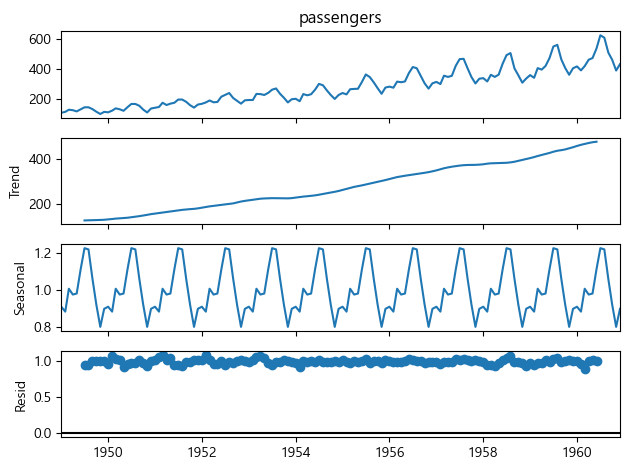

In [12]:
# 시계열분해

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['passengers'], model='multiplicative', period=12)

fig = decomposition.plot()
plt.tight_layout()
plt.show()

차분 ADF Statistic: -16.384231542468527
차분 p-value: 2.732891850014085e-29
✅ 정상 시계열 (stationary)


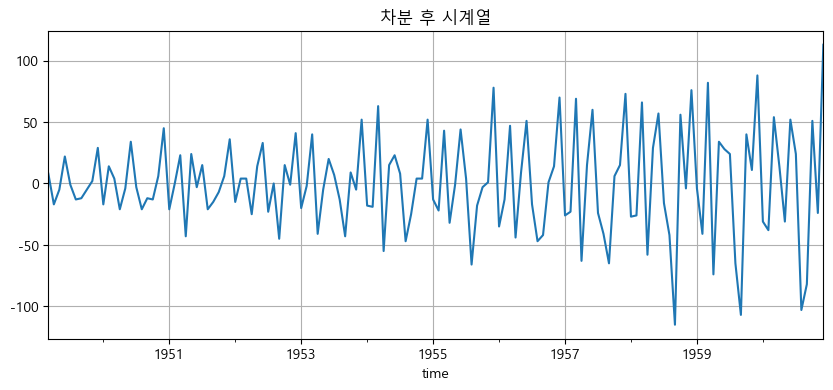

In [13]:
# ARIMA 이용 1년 예측

df_diff = df['passengers'].diff().diff().dropna()

adf_result_diff = adfuller(df_diff)
print("차분 ADF Statistic:", adf_result_diff[0])
print("차분 p-value:", adf_result_diff[1])
if adf_result_diff[1] < 0.05:
    print("✅ 정상 시계열 (stationary)")
else:
    print("❌ 비정상 시계열 → 차분 필요")

df_diff.plot(title="차분 후 시계열", figsize=(10, 4))
plt.grid(True)
plt.show()

In [14]:
model = ARIMA(df['passengers'], order=(2, 2, 1))
result = model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:             passengers   No. Observations:                  144
Model:                 ARIMA(2, 2, 1)   Log Likelihood                -692.943
Date:                Thu, 18 Dec 2025   AIC                           1393.887
Time:                        23:48:42   BIC                           1405.710
Sample:                    01-01-1949   HQIC                          1398.691
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3845      0.092      4.194      0.000       0.205       0.564
ar.L2         -0.2259      0.071     -3.181      0.001      -0.365      -0.087
ma.L1         -0.9987      0.676     -1.478      0.1

c:\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


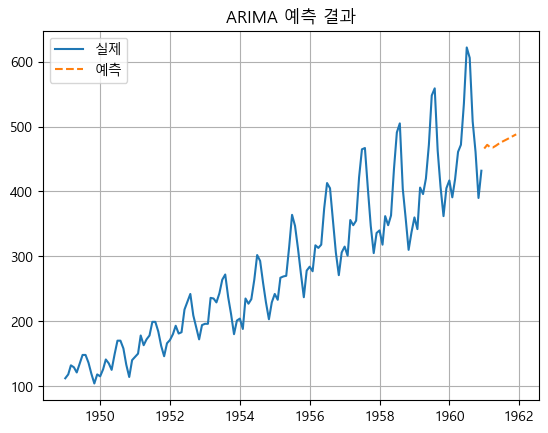

In [15]:
forecast = result.forecast(steps=12)

plt.plot(df['passengers'], label="실제")
plt.plot(pd.date_range(start=df.index[-1], periods=12, freq='M'), forecast, label="예측", linestyle='--')
plt.title("ARIMA 예측 결과")
plt.legend()
plt.grid(True)
plt.show()

c:\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


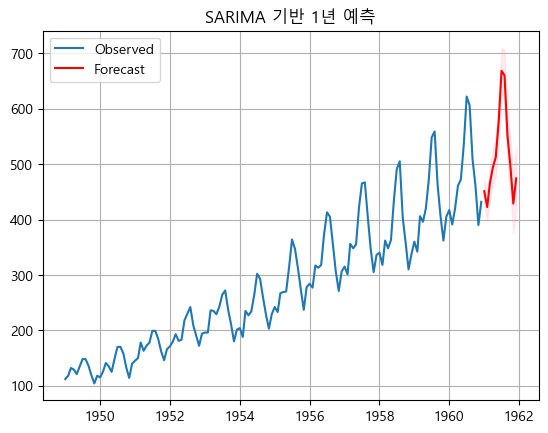

In [16]:
# SARIMA 이용 1년 예측

from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df['passengers'], order=(2,2,1), seasonal_order=(1,2,1,12))
result = model.fit()

# 향후 12개월 예측
forecast = result.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# 시각화
plt.plot(df.index, df['passengers'], label='Observed')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_mean.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.title("SARIMA 기반 1년 예측")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# autoarima 이용 1년 예측

from pmdarima import auto_arima

stepwise_model = auto_arima(
    df['passengers'],
    seasonal=True,
    m=12,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print('=========================')
print("최적 모델 요약:")
stepwise_model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=0.46 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.05 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.07 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=0.28 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.10 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=0.28 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.05 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.09 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=0.25 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=0.23 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=0.48 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.03 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.03 sec
 ARIMA(3,1,1)(0,1,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -504.923
Date:                             Thu, 18 Dec 2025   AIC                           1017.847
Time:                                     23:48:46   BIC                           1029.348
Sample:                                 01-01-1949   HQIC                          1022.520
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5960      0.085      6.987      0.000       0.429       0.763
ar.L2          0.2143      0.091      2.343      0.019       0.035       0.394
ma.L1         -0.9819      0.038    -25.599      0.000      -1.057      -0.907
sigma2       129.3129     14.556      8.884      0.000     100.783     157.843
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 7.68
Prob(Q):                              0.98   Prob(JB):                         0.02
Heteroskedasticity (H):               2.33   Skew:                            -0.01
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

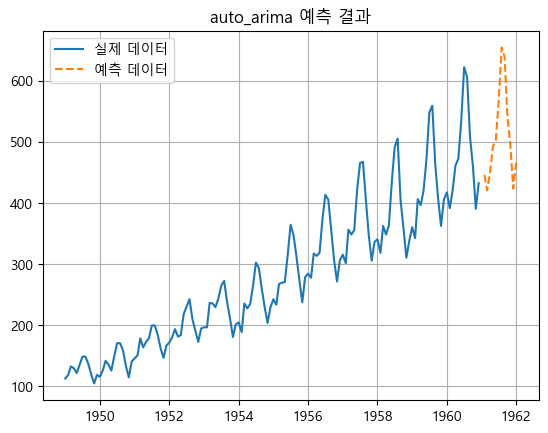

In [18]:
n_periods = 12
forecast = stepwise_model.predict(n_periods=n_periods)

# 6️ 실제 + 예측 시각화
plt.plot(df['passengers'], label='실제 데이터')
plt.plot(pd.date_range(start=df['passengers'].index[-1], periods=n_periods+1, freq='M')[1:], forecast, label='예측 데이터', linestyle='--')
plt.title("auto_arima 예측 결과")
plt.legend()
plt.grid(True)
plt.show()
